<a href="https://colab.research.google.com/github/koscielnamarta/vet-eye-ai-usg-demo/blob/main/01_first_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Sprawdzamy, czy Colab przydzielił nam fizyczne GPU
# nvidia-smi to narzędzie systemu Linux pokazujące status karty NVIDIA
# (model, ilość pamięci VRAM, użycie, sterowniki)
!nvidia-smi

Tue May  5 21:52:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Teraz sprawdzamy, czy PyTorch (biblioteka, której będziemy używać do modeli)
# widzi GPU przez CUDA. CUDA to platforma NVIDII pozwalająca odpalać kod
# na karcie graficznej zamiast na CPU — w deep learningu różnica to 10-100x
# szybciej, więc bez tego nie ma co startować.

import torch

print(f"Wersja PyTorch: {torch.__version__}")
print(f"CUDA dostępne: {torch.cuda.is_available()}")
print(f"Liczba widocznych GPU: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"Nazwa GPU: {torch.cuda.get_device_name(0)}")
    # 1024**3 zamienia bajty na gigabajty (1024 razy 1024 razy 1024)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM (pamięć karty): {vram_gb:.1f} GB")
else:
    print("UWAGA: GPU niedostępne — sprawdź Runtime → Change runtime type")

Wersja PyTorch: 2.10.0+cu128
CUDA dostępne: True
Liczba widocznych GPU: 1
Nazwa GPU: Tesla T4
VRAM (pamięć karty): 14.6 GB


In [5]:
# ─────────────────────────────────────────────────────────────────
# Krok 3: Pobranie FETAL_PLANES_DB z Zenodo na Google Drive
# ─────────────────────────────────────────────────────────────────

# Mount Drive — Google Drive zostanie podłączony jako folder /content/drive,
# czyli będziemy mogli pisać i czytać pliki z Drive jak ze zwykłego dysku.
# Po uruchomieniu pojawi się link do autoryzacji — kliknij, wybierz konto,
# zaakceptuj uprawnienia. Zwróci kod, który Colab automatycznie podstawi.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ─────────────────────────────────────────────────────────────────
# Krok 3D: Pobranie FETAL_PLANES_DB z Zenodo na Google Drive
# ─────────────────────────────────────────────────────────────────

# `zenodo_get` to gotowe narzędzie pythonowe, które ściąga cały rekord Zenodo
# po DOI — sprawdza checksumy MD5, obsługuje retry, nie musimy ręcznie
# kopiować URL-i. Flaga -q (quiet) wycisza output instalacji.
!pip install zenodo_get -q

# Tworzymy folder na dataset w Drive (jeśli już istnieje, nic się nie stanie
# dzięki exist_ok=True). MyDrive to katalog główny Twojego Google Drive.
import os
DATA_DIR = '/content/drive/MyDrive/vet_eye_demo/data'
os.makedirs(DATA_DIR, exist_ok=True)

# Magia Colaba: %cd zmienia katalog roboczy na trwałe (dla całej komórki),
# w odróżnieniu od !cd, które zmienia tylko w obrębie jednego polecenia shell.
%cd $DATA_DIR

# zenodo_get pobiera wszystkie pliki z rekordu o danym DOI do bieżącego folderu
# Dla 10.5281/zenodo.3904280 = 1 plik FETAL_PLANES_ZENODO.zip (2.1 GB)
!zenodo_get 10.5281/zenodo.3904280

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.8 MB/s eta 0:00:00
/content/drive/MyDrive/vet_eye_demo/data
INFO: Output directory: /content/drive/MyDrive/vet_eye_demo/data
INFO: Title: FETAL_PLANES_DB: Common maternal-fetal ultrasound images
INFO: Total size: 2.1 GB
INFO: Number of files: 1
SUCCESS: All specified files have been processed.


In [7]:
# Sprawdzenie, czy plik się ściągnął w całości i nie jest uszkodzony.
# md5 to "odcisk palca" pliku — po pobraniu liczymy własny i porównujemy
# z deklarowanym przez Zenodo (2a5fcc2cefb789bcc0f6c1f73e0ea43f).
# Jeśli się nie zgadza, plik jest uszkodzony — pobieramy ponownie.

import hashlib

ZIP_PATH = f'{DATA_DIR}/FETAL_PLANES_ZENODO.zip'
EXPECTED_MD5 = '2a5fcc2cefb789bcc0f6c1f73e0ea43f'

print(f"Liczę md5 pliku {ZIP_PATH}...")
md5 = hashlib.md5()
with open(ZIP_PATH, 'rb') as f:
    # Czytamy plik w paczkach po 8 MB, żeby nie ładować 2 GB do RAM-u naraz
    for chunk in iter(lambda: f.read(8 * 1024 * 1024), b''):
        md5.update(chunk)

calculated = md5.hexdigest()
print(f"Obliczone md5: {calculated}")
print(f"Oczekiwane md5: {EXPECTED_MD5}")
print(f"Zgodność: {'✅ OK' if calculated == EXPECTED_MD5 else '❌ BŁĄD — pobierz ponownie'}")

Liczę md5 pliku /content/drive/MyDrive/vet_eye_demo/data/FETAL_PLANES_ZENODO.zip...
Obliczone md5: 2a5fcc2cefb789bcc0f6c1f73e0ea43f
Oczekiwane md5: 2a5fcc2cefb789bcc0f6c1f73e0ea43f
Zgodność: ✅ OK


In [8]:
# ═══════════════════════════════════════════════════════════════
# Krok 5A: Rozpakowanie FETAL_PLANES_ZENODO.zip do /content/
# ═══════════════════════════════════════════════════════════════
# Z Drive (wolne I/O) do /content (szybkie SSD) — kopiujemy zip i rozpakujemy.
import shutil, os, zipfile, time

ZIP_DRIVE = '/content/drive/MyDrive/vet_eye_demo/data/FETAL_PLANES_ZENODO.zip'
ZIP_LOCAL = '/content/FETAL_PLANES.zip'
EXTRACT_DIR = '/content/fetal_planes'

print("Kopiuję zip z Drive do /content (szybsze niż unzip prosto z Drive)...")
t0 = time.time()
shutil.copy(ZIP_DRIVE, ZIP_LOCAL)
print(f"  Skopiowane w {time.time()-t0:.1f}s")

print("Rozpakowuję...")
t0 = time.time()
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_LOCAL, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f"  Rozpakowane w {time.time()-t0:.1f}s")

# Sanity: ile obrazów + jaki CSV
!ls $EXTRACT_DIR
!ls $EXTRACT_DIR/Images | head -5
!echo "Liczba obrazów:"; ls $EXTRACT_DIR/Images | wc -l

Kopiuję zip z Drive do /content (szybsze niż unzip prosto z Drive)...
  Skopiowane w 11.7s
Rozpakowuję...
  Rozpakowane w 10.0s
FETAL_PLANES_DB_data.csv  FETAL_PLANES_DB_data.xlsx  Images  README.md
Patient00001_Plane1_10_of_15.png
Patient00001_Plane1_11_of_15.png
Patient00001_Plane1_12_of_15.png
Patient00001_Plane1_13_of_15.png
Patient00001_Plane1_14_of_15.png
Liczba obrazów:
12400


In [9]:
# ═══════════════════════════════════════════════════════════════
# Krok 5B: Sklonowanie TinyUSFM + pobranie checkpointa
# ═══════════════════════════════════════════════════════════════
# Każdy notebook ma własny /content, więc musimy skopiować w to miejsce.
!git clone -q https://github.com/MacDunno/TinyUSFM.git /content/TinyUSFM
!pip install -q --upgrade gdown
!mkdir -p /content/checkpoints
!gdown 1P_wDuU-StALLJEBaymioaYu52CScW-l- -O /content/checkpoints/TinyUSFM.pth
!ls -la /content/checkpoints/

Downloading...
From: https://drive.google.com/uc?id=1P_wDuU-StALLJEBaymioaYu52CScW-l-
To: /content/checkpoints/TinyUSFM.pth
100% 22.1M/22.1M [00:00<00:00, 54.8MB/s]
total 21636
drwxr-xr-x 2 root root     4096 May  5 22:58 .
drwxr-xr-x 1 root root     4096 May  5 22:57 ..
-rw------- 1 root root 22143816 Feb  9 03:15 TinyUSFM.pth


In [10]:
# ═══════════════════════════════════════════════════════════════
# Krok 5C: Instalacja timm==0.5.4 (wersja z requirements.txt repo)
# ═══════════════════════════════════════════════════════════════
# UWAGA: Jeśli wyskoczy "Restart runtime", kliknij i uruchom wszystkie
# komórki od początku (Runtime → Run all). Pliki na dysku zostaną.
!pip install -q timm==0.5.4
import timm
print(f"timm: {timm.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 31.3 MB/s eta 0:00:00
timm: 0.5.4


In [11]:
# ═══════════════════════════════════════════════════════════════
# Krok 5D: Załadowanie modelu TinyUSFM na GPU
# ═══════════════════════════════════════════════════════════════
import torch, sys
sys.path.insert(0, '/content/TinyUSFM')
from model.tinyusfm import TinyUSFM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Urządzenie: {device}")

# Tworzymy model dla 6 klas i przenosimy NA GPU
model = TinyUSFM(num_classes=6, global_pool=True).to(device)

# Ładujemy pretrained wagi
ckpt = torch.load(
    '/content/checkpoints/TinyUSFM.pth',
    map_location=device,
    weights_only=True
)
load_info = model.load_state_dict(ckpt, strict=False)
print(f"Missing keys: {load_info.missing_keys}")
print(f"Unexpected keys: {load_info.unexpected_keys}")

model.eval()  # tryb predykcji (wyłącza dropout)
print(f"\nModel gotowy. Parametry: {sum(p.numel() for p in model.parameters()):,}")

Urządzenie: cuda
Missing keys: ['model.head.weight', 'model.head.bias', 'model.fc_norm.weight', 'model.fc_norm.bias']
Unexpected keys: ['model.norm.weight', 'model.norm.bias']

Model gotowy. Parametry: 5,525,574


Kolumny CSV: ['Image_name', 'Patient_num', 'Plane', 'Brain_plane', 'Operator', 'US_Machine', 'Train ']
Liczba wierszy: 12400
Pierwsze 3 wiersze:
                    Image_name  Patient_num  Plane  Brain_plane Operator  \
0  Patient00001_Plane1_1_of_15            1  Other  Not A Brain    Other   
1  Patient00001_Plane1_2_of_15            1  Other  Not A Brain    Other   
2  Patient00001_Plane1_3_of_15            1  Other  Not A Brain    Other   

  US_Machine  Train   
0      Aloka       1  
1      Aloka       1  
2      Aloka       1  

Unikatowe klasy w kolumnie 'Plane' (lub podobnej):
  Wykryta kolumna labelek: 'Plane'
  Klasy: ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']

── Wybrany obraz ──
  Plik: Patient00736_Plane4_2_of_2
  Prawdziwa klasa: Maternal cervix
  Ścieżka: /content/fetal_planes/Images/Patient00736_Plane4_2_of_2.png

── Predykcja modelu (head losowy, więc to zgadywanie) ──
  Klasa 0 (Fetal abdomen                 ): 0.2256

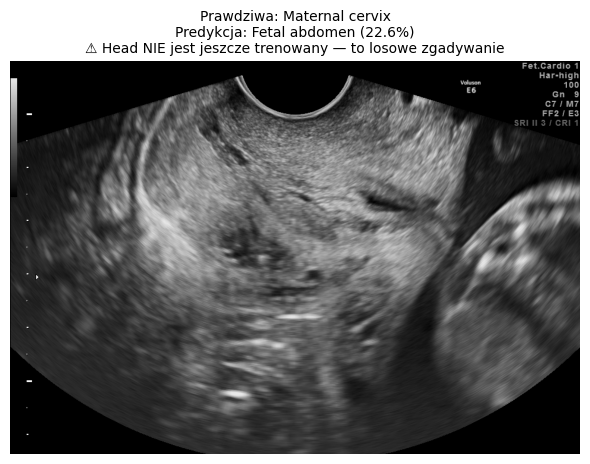


✅ Krok 5E: Definition of Done Tygodnia 1 osiągnięty.
   Pipeline działa: obraz → preprocessing → model → predykcja + wizualizacja.


In [12]:
# ═══════════════════════════════════════════════════════════════
# Krok 5E: Predykcja na 1 losowym obrazie z FETAL_PLANES_DB
# ═══════════════════════════════════════════════════════════════
import pandas as pd
from PIL import Image
import torchvision.transforms as T
import random
import matplotlib.pyplot as plt

# ── Wczytanie CSV z labelkami ──
# Próbujemy najpierw separator ';' (europejski standard, używa go Burgos-Artizzu).
# Jeśli zwróci 1 kolumnę, próbujemy ','.
CSV_PATH = f'{EXTRACT_DIR}/FETAL_PLANES_DB_data.csv'
df = pd.read_csv(CSV_PATH, sep=';')
if len(df.columns) == 1:
    df = pd.read_csv(CSV_PATH, sep=',')

print(f"Kolumny CSV: {list(df.columns)}")
print(f"Liczba wierszy: {len(df)}")
print(f"Pierwsze 3 wiersze:\n{df.head(3)}")
print(f"\nUnikatowe klasy w kolumnie 'Plane' (lub podobnej):")

# Heurystyka: szukamy kolumny z labelkami klas
label_col = None
for col in df.columns:
    if df[col].dtype == 'object' and df[col].nunique() <= 10:
        label_col = col
        break
print(f"  Wykryta kolumna labelek: '{label_col}'")
print(f"  Klasy: {sorted(df[label_col].unique())}")

# ── Wybór losowego obrazu ──
random.seed(42)  # dla powtarzalności
sample = df.sample(1, random_state=42).iloc[0]
img_name_col = [c for c in df.columns if 'image' in c.lower() or 'name' in c.lower() or 'file' in c.lower()][0]
img_filename = sample[img_name_col]
true_label = sample[label_col]

# Ścieżka do obrazu (dodajemy .png jeśli nie ma)
img_path = f'{EXTRACT_DIR}/Images/{img_filename}'
if not os.path.exists(img_path):
    img_path = f'{EXTRACT_DIR}/Images/{img_filename}.png'

print(f"\n── Wybrany obraz ──")
print(f"  Plik: {img_filename}")
print(f"  Prawdziwa klasa: {true_label}")
print(f"  Ścieżka: {img_path}")

# ── Preprocessing: resize, RGB, normalizacja ImageNet ──
img_pil = Image.open(img_path).convert('RGB')  # konwersja grayscale → RGB
preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = preprocess(img_pil).unsqueeze(0).to(device)  # batch dim + GPU

# ── Forward pass ──
with torch.no_grad():
    logits = model(img_tensor)
probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

# Mapowanie klas
classes_sorted = sorted(df[label_col].unique())
print(f"\n── Predykcja modelu (head losowy, więc to zgadywanie) ──")
for i, cls in enumerate(classes_sorted):
    marker = ' ← TOP' if i == probs.argmax() else ''
    print(f"  Klasa {i} ({cls:30s}): {probs[i]:.4f}{marker}")

# ── Wizualizacja ──
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(img_pil, cmap='gray')
ax.set_title(
    f"Prawdziwa: {true_label}\n"
    f"Predykcja: {classes_sorted[probs.argmax()]} ({probs.max():.1%})\n"
    f"⚠️ Head NIE jest jeszcze trenowany — to losowe zgadywanie",
    fontsize=10
)
ax.axis('off')
plt.tight_layout()
plt.savefig('/content/first_inference_result.png', dpi=80, bbox_inches='tight')
plt.show()
print("\n✅ Krok 5E: Definition of Done Tygodnia 1 osiągnięty.")
print("   Pipeline działa: obraz → preprocessing → model → predykcja + wizualizacja.")